Environment name: `r_env_corr`

# 0. - Imports and paths

In [1]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [2]:
source("./utils/source_satac.R")
library(biovizBase)
library(extrafont) # install.packages("extrafont")

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: ensembldb

Loading required package: GenomicRanges

Loa

Loading the fonts.

In [3]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf 
# or, better, https://fonts.google.com/specimen/DM+Sans
# Import only DMSans-Medium
font_import(paths = "../fonts/static/", prompt = FALSE, recursive = FALSE, pattern = "DMSans-Medium.ttf") # select just the Medium one
loadfonts()  # Load registered fonts

# verify if the font is available:
fonts()

Scanning ttf files in ../fonts/static/ ...

Extracting .afm files from .ttf files...

/disk2/user/gabgam/the_project/fonts/static/DMSans-Medium.ttf


 : DMSans-Medium already registered in fonts database. Skipping.

Found FontName for 0 fonts.

Scanning afm files in /disk2/user/gabgam/miniconda3/envs/r_env_corr/lib/R/library/extrafontdb/metrics

DM Sans Medium already registered with pdfFont().

DM Sans Medium already registered with postscriptFont().



[1] "DM Sans Medium"

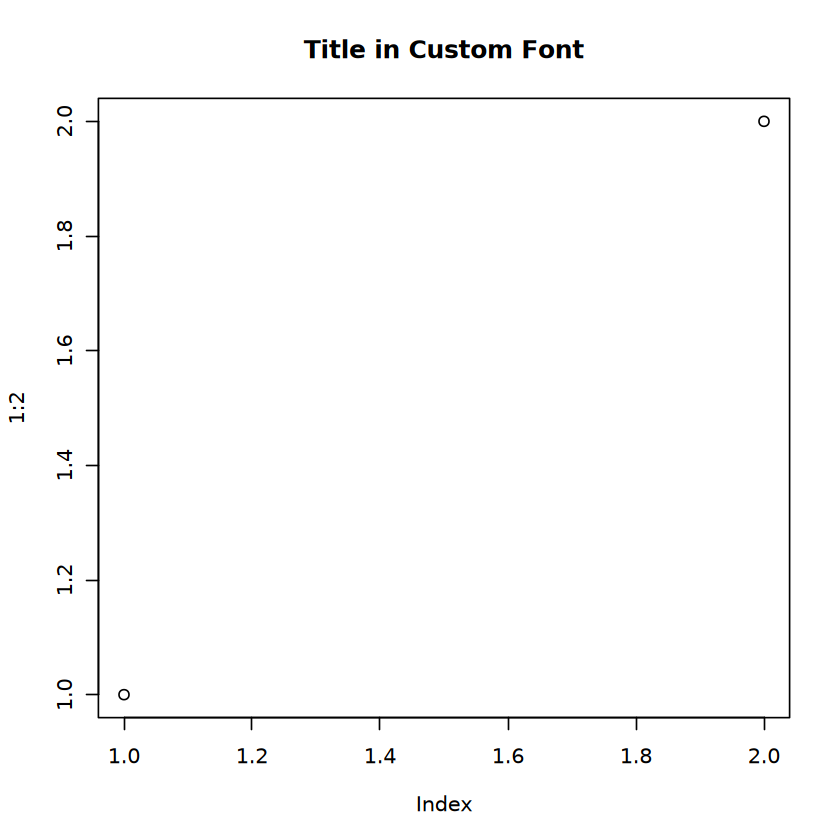

In [4]:
# for font in Base R plots
par(family = "DM Sans Medium")
plot(1: 2, main = "Title in Custom Font")

In [6]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"
PATH_sATAC_PREPROCESSING_OUTPUT <- "output/sATAC_preprocessing/"
PATH_TO_FIGURES <- "figures/sATAC_preprocessing/"

SELECTED_sATAC_SAMPLE <- "220327_C1"

# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
BRCA_PEAK_CALLS <- paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/BRCA_peakCalls.csv")

---
# 1. - Creating the initial Object

## 1.1 - Creating table with paths to all files

In [7]:
# set paths to raw data and metadata
dirs <- list.dirs(paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/"), recursive = F, full.names = F)
table <- list()


# create a table containing paths to raw and meta data (i.e., output from cellranger + spatial info)
for(i in dirs){
  table[[i]] <- list(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/raw_peak_bc_matrix.h5"),
                  singlecell = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/singlecell.csv"),
                  fragments = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/fragments.tsv.gz"),
                  tissue_paths = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.tsv"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()
#infoTable <- as.data.frame(table, stringsAsFactors = FALSE)


## 1.2 - Creating count Object for peaks

From the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette):
```r
fragpath <- '10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz'

# Define cells
# If you already have a list of cell barcodes to use you can skip this step
total_counts <- CountFragments(fragpath)
cutoff <- 1000 # Change this number depending on your dataset!
barcodes <- total_counts[total_counts$frequency_count > cutoff, ]$CB

# Create a fragment object
frags <- CreateFragmentObject(path = fragpath, cells = barcodes)

# First call peaks on the dataset
# If you already have a set of peaks you can skip this step
peaks <- CallPeaks(frags)

# Quantify fragments in each peak
counts <- FeatureMatrix(fragments = frags, features = peaks, cells = barcodes)
```


In [8]:
object <- list(md = list(),
               frag = list(),
               counts = list())

# build new matrices with new peak set
# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
# load peaks and create genomicranges object
gr <- read.csv(
  file = BRCA_PEAK_CALLS,
  col.names = c("chr", "start", "end"),
  sep = ";"
) %>% makeGRangesFromDataFrame()

# create fragment objects and count matrices for each section separately
for(i in seq_along(dirs)){
  # folder = paste0(PATH_TO_sATAC_DATA_FOLDER, "combined/")
  folder = strsplit(infoTable$samples[[i]], "raw_peak_bc_matrix.h5") %>% unlist()
  # load metadata
  object$md[[i]] <- read.table(
    file = infoTable$singlecell[[i]],
    stringsAsFactors = FALSE,
    sep = ",",
    header = TRUE,
    row.names = 1
  )[-1, ] # remove the first row (NO_BARCODE)
  
  # create fragment objects
  object$frag[[i]] <- CreateFragmentObject(
    path = infoTable$fragments[[i]],
    cells = rownames(object$md[[i]])
  )
  
  if (file.exists(paste0(folder, "brca_peak_bc_matrix.h5"))) {
    message("File exists.")
    object$counts[[i]] <- Read10X_h5(paste0(folder, "brca_peak_bc_matrix.h5"))
    
  } else {
    
    # make count matrix
    object$counts[[i]] <- FeatureMatrix(
      fragments = object$frag[[i]],
      features = gr,
      cells = rownames(object$md[[i]])
    )
    
    write10xCounts(path = paste0(folder, "brca_peak_bc_matrix.h5"),
                   x = object$counts[[i]],
                   type = "HDF5") # save new count matrix
  }
  
}

Computing hash

File exists.

Computing hash

File exists.

Computing hash

File exists.



## 1.3 - Building the correct tissue list file

In [9]:
# make tissue position files
for(i in seq_along(infoTable$tissue_paths)){
  spotfile <- read.table(infoTable$tissue_paths[[i]], sep = "\t", header = T)
  
  spotfile_tissue <- cbind(
    spotfile$row, #array_row
    spotfile$col, #array_col
    spotfile$x, #pxl_row_in_fullres
    spotfile$y #pxl_col_in_fullres
  ) %>% as.data.frame()
  tissue <- rep(1, nrow(spotfile_tissue))
  spotfile_tissue <- cbind(tissue, spotfile_tissue)
  rownames(spotfile_tissue) <- paste0(spotfile$barcode, "-1")
  
  # save new tissue position file with the correct columns for creating STutility object as .csv files
  write.csv(spotfile_tissue, 
            paste0(strsplit(infoTable$tissue_paths[[i]], "tsv"), "csv"), 
            sep = ",")
  
}

Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"


Loading the files just created for each of the sections.

In [10]:
# load spotfiles
tissue_md <- list()
object$mtx <- list()

for(i in seq_along(infoTable$spotfiles)){
  spotfile <- read.csv(infoTable$spotfiles[[i]],
                       col.names = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x")
  )
  
  # filter count matrix to retain only spots overlaying tissue
  mtx <- object$counts[[i]] # barcodes extracted from here
  mtx <- mtx[,colnames(mtx) %in% spotfile$barcode] 
  
  object$mtx[[i]] <- mtx
  
  #save spot info in a list
  tissue_md[[i]] <- spotfile
}

---
# 2. - Chromatin Assay object and LSI computing
why do they perform normalisation here???

No Quality control when importing the fragments. In the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette) they do:
```r
chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz",
  min.cells = 10,
  min.features = 200
)
```

They didn't even remove the features that correspond to chromosome scaffolds or sequences that aren't part of standard chromosomes like in the tutorial.

In [11]:
signac_object <- list()

# create signac objects for each section and run normalization and dimensionality reduction
for(i in seq_along(infoTable$spotfiles)){
  assay <- CreateChromatinAssay(object$mtx[[i]], 
                                fragments = object$frag[[i]])
  
  signac_object[[i]] <- CreateSeuratObject(assay, 
                                           assay = "peaks", 
                                           meta.data=object$md[[i]])
  signac_object[[i]]$section <- rownames(infoTable)[i]
  # signac_object[[i]]$sample <- i
  signac_object[[i]]$sample <- rownames(infoTable)[i]
  # compute LSI
  signac_object[[i]] <- FindTopFeatures(signac_object[[i]], min.cutoff = 10)
  signac_object[[i]] <- RunTFIDF(signac_object[[i]])
  signac_object[[i]] <- RunSVD(signac_object[[i]])
}

Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings

Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"
Running SVD

Scaling cell embeddings

Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :


normalised with LSI.

The normalisation happens on the `data` object.

## 2.1 - Merging all the sections

In [13]:
signac_object

[[1]]
An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 104036 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: lsi

[[2]]
An object of class Seurat 
215978 features across 2795 samples within 1 assay 
Active assay: peaks (215978 features, 100657 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: lsi

[[3]]
An object of class Seurat 
215978 features across 3533 samples within 1 assay 
Active assay: peaks (215978 features, 102608 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: lsi


In [ ]:
# merge objects
# combined <- merge(
#   x = signac_object[[1]],
#   y = c(signac_object[2:length(dirs)])
# )

# table(combined$section)

# add spatial data to meta
for(i in seq_along(infoTable$tissue_paths)){
  tissue_md[[i]]$barcode <- paste0(tissue_md[[i]]$barcode, "_", i)
  rownames(tissue_md[[i]]) <- tissue_md[[i]]$barcode 
}

# tissue_md_combined <- do.call("rbind", tissue_md) 
# combined <- AddMetaData(combined, tissue_md_combined)

Warning message:
"Some cell names are duplicated across objects provided. Renaming to enforce unique cell names."


Warning message in CreateChromatinAssay(counts = merged.counts, min.cells = -1, :
"Overlapping ranges supplied. Ranges should be non-overlapping."



220327_C1 220327_C2 220327_D2 
     3538      2795      3533 

Don't add the image as mine has already been processed.

In [42]:
infoTable$spotfiles

$`220327_C1`
[1] "../data/spatial_atac/github_folder/meta/220327_C1_tissue.csv"

$`220327_C2`
[1] "../data/spatial_atac/github_folder/meta/220327_C2_tissue.csv"

$`220327_D2`
[1] "../data/spatial_atac/github_folder/meta/220327_D2_tissue.csv"

## 2.2 - Adding the images

In [43]:
# add image
# image is manually cropped so that it only shows the capture area
table <- list()
for(i in dirs){
  table[[i]] <- c(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/brca_peak_bc_matrix.h5"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"),
                  imgs = paste0(PATH_TO_sATAC_DATA_FOLDER, "spatial/", i, "_cropped.jpg"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()

for (i in 1:length(dirs)) {
  # Read *_tissue.csv file
  xy.raw <- setNames(read.csv(file = infoTable$spotfiles[i]), 
                     nm = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x"))
  xy <- xy.raw[, c("x", "y")]
  
  img_path <- infoTable$imgs[i]
  img <- readJPEG(img_path)
  
  sf <- c(ncol(img)/128, nrow(img)/78)
  xy$x <- xy$x*sf[1]
  xy$y <- xy$y*sf[2]
  
  # Create a new spot selection table with proper image pixel coordinates which match the cropped images
  spotfile <- data.frame(xy.raw$barcode, xy.raw$tissue, xy.raw$y, xy.raw$x, round(xy$y), round(xy$x))
  write.table(spotfile, file = paste0(strsplit(infoTable$spotfiles[i], ".csv"), "_positions_list.csv"), 
              sep = ",", quote = F, row.names = F, col.names = F)
}

infoTable$spotfiles <- paste0(strsplit(infoTable$spotfiles, ".csv"), "_positions_list.csv")
se <- InputFromTable(infoTable, scaleVisium = 1)
se <- LoadImages(se, time.resolve = F)
combined@tools[["Staffli"]] <- se@tools$Staffli # create STutility object for spatial plots

Using spotfiles to remove spots outside of tissue


Warning message:
"No scalefactors provided for Visium samples ... 
"


Loading ../data/spatial_atac/outs/220327_C1/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"


Loading ../data/spatial_atac/outs/220327_C2/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"


Loading ../data/spatial_atac/outs/220327_D2/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 4.5 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"



------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  102  
After filtering the dimensions of the experiment is: [215876 genes, 9866 spots] 
Loading images for 3 samples: 
  Reading ../data/spatial_atac/spatial/220327_C1_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10914x11438 pixels to 400x419 pixels 
  Reading ../data/spatial_atac/spatial/220327_C2_cropped.jpg for sample 1 ... 
  Scaling down sample 2 image from 10913x11438 pixels to 400x419 pixels 
  Reading ../data/spatial_atac/spatial/220327_D2_cropped.jpg for sample 1 ... 
  Scaling down sample 3 image from 10914x11438 pixels to 400x419 pixels 


Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'



---

## 2.3. - Selecting just my sample

In [ ]:
# Extract Only `220327_C1`
signac_filtered <- subset(combined, subset = sample == SELECTED_sATAC_SAMPLE)


# Save Processed Object
# saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, paste0("2", SELECTED_sATAC_SAMPLE, "_signac_object.rds")))
# saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, paste0("2_", SELECTED_sATAC_SAMPLE, "_selected_signac_object.rds")))

# Print Summary
print(signac_filtered)

An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data


In [45]:
table(combined$sample)


220327_C1 220327_C2 220327_D2 
     3538      2795      3533 

In [46]:
table(signac_filtered$sample)


220327_C1 
     3538 

In [47]:
dim(combined)
dim(signac_filtered)

[1] 215978   9866

[1] 215978   3538

# 3. - Computing LSI normalisation and clustering
I don't think that I should normalise once again.

In [48]:
#preprocess raw data
signac_filtered <- signac_filtered %>% 
  RunTFIDF() %>%
  FindTopFeatures(min.cutoff = 'q0') %>%
  RunSVD()

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"


Running SVD

Scaling cell embeddings



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"


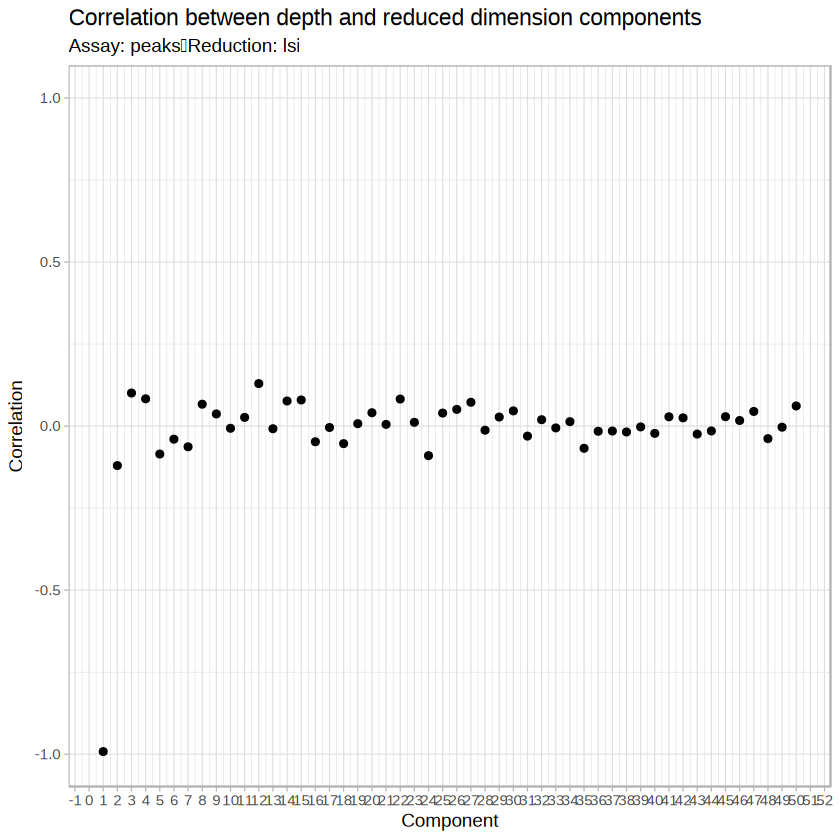

In [49]:
DepthCor(signac_filtered, n = 50)

Here we see there is a very strong correlation between the first LSI component and the total number of counts for the cell. We will perform downstream steps without this component as we don’t want to group cells together based on their total sequencing depth, but rather by their patterns of accessibility at cell-type-specific peaks.

And then they choose 7 components, while in the tutorial, they go for `2:30`.

In [50]:
signac_filtered <- signac_filtered %>%
  RunUMAP(reduction = 'lsi', dims = 2:25, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:25, verbose = FALSE) %>%
  FindClusters(algorithm = 3, resolution = 0.5, verbose = FALSE)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


## 3.1 - Plotting by clusters

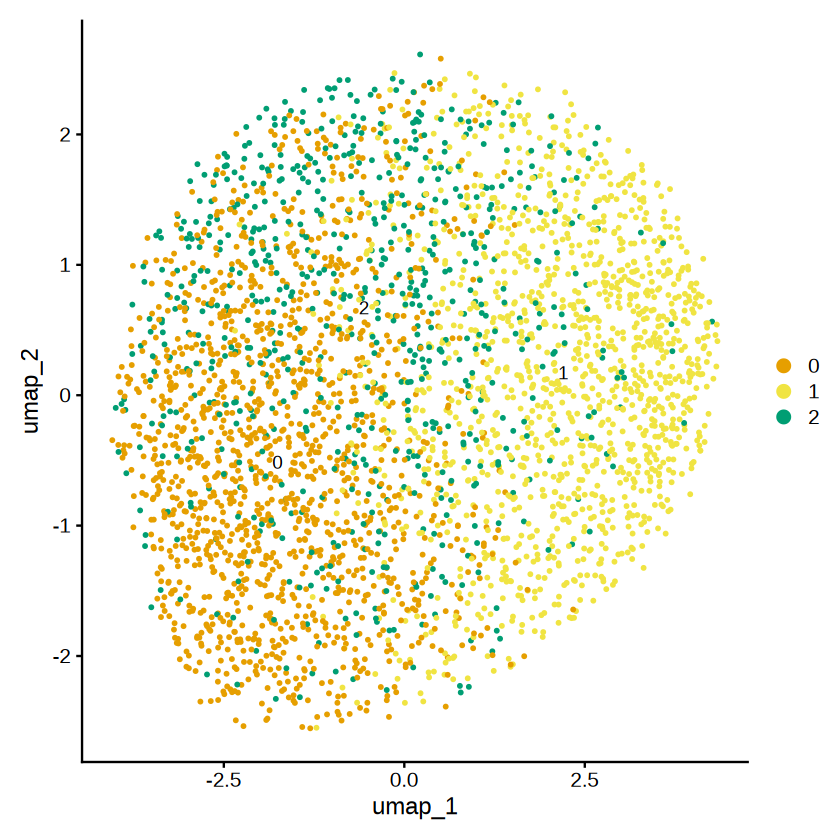

In [ ]:
DimPlot(object = signac_filtered, reduction = "umap", cols=colors_okate)# + NoLegend()

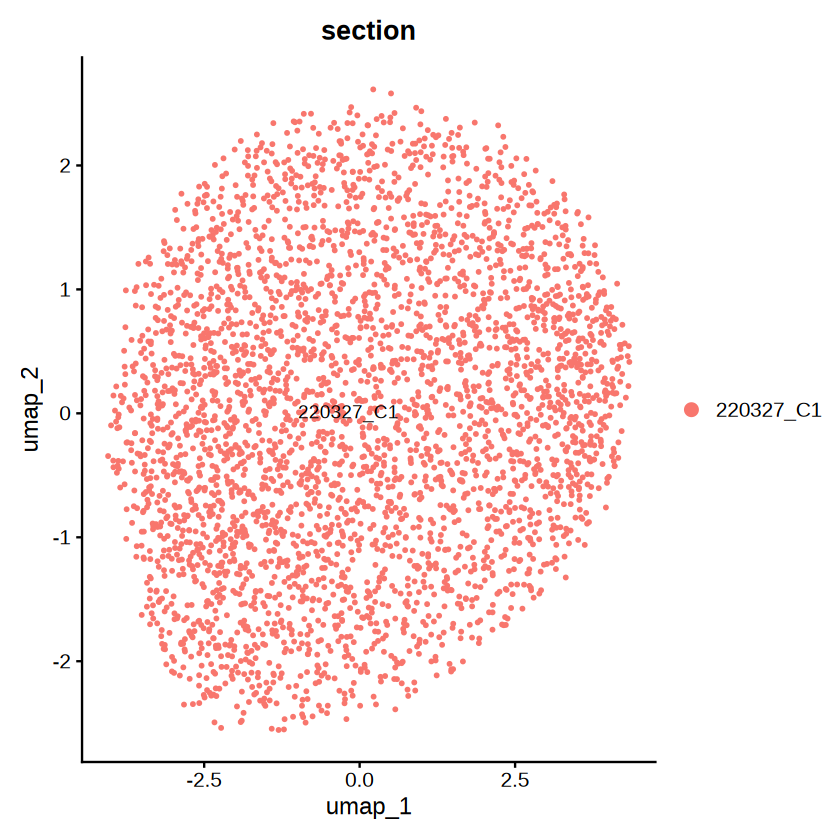

In [ ]:
DimPlot(object = signac_filtered, reduction = "umap", group.by = "section")# + NoLegend()

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on '500 μm' in 'mbcsToSbcs': for μ (U+03BC)"


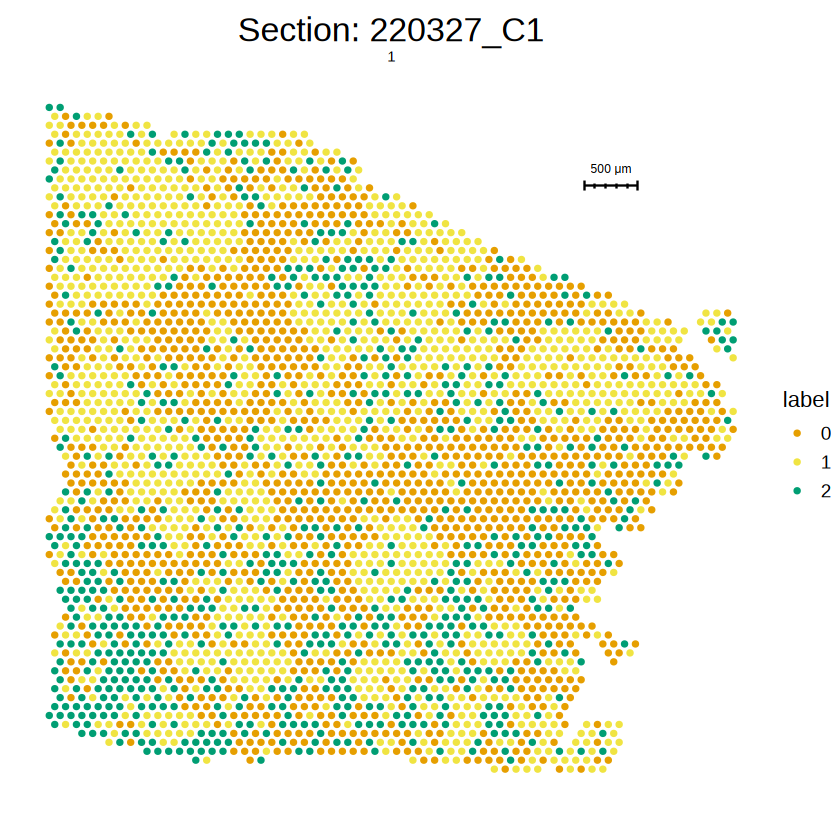

In [60]:
for (sec in unique(signac_filtered$section)) {
    p <- ST.FeaturePlot(subset(signac_filtered, section == sec), 
                        features = "seurat_clusters", 
                        cols = colors_okate,
                        pt.size = 1.8) +
         ggtitle(paste("Section:", sec)) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    plot_file_name <- paste0(PATH_TO_FIGURES, "Cluster_plot_for_selected_", sec, ".pdf")
    ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

## 3.2 - Saving the normalised output

in the original code they use `data`, but that's the normalised matrix.

In [ ]:
# #save normalised data matrix for denoising
# write.csv(signac_filtered@assays$peaks@data,
#         paste0("./output/sATAC_preprocessing/data_signac_", SELECTED_sATAC_SAMPLE, "_filtered_brca_q0_peak_bc_matrix.csv"))

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"


Save the R session as `.RDS` file.

In [ ]:
saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "1_selected_", SELECTED_sATAC_SAMPLE, "_brca.rds"))

---
# 4. - DCA - Peaks denoiser

On terminal, in a Python environment with TensorFlow and the DCA package installed, such as `dca_mamba_37` run:\
  - for prenormalised data:
```sh
nohup dca output/sATAC_preprocessing/data_signac_<SECTION_NAME>_filtered_brca_q0_peak_bc_matrix.csv output/sATAC_preprocessing/dated_dca_<SECTION_NAME>_peaks_q0_brca --threads 3 --nosizefactors --nonorminput --nologinput --saveweights --nocheckcounts > nohup_for_dca_data.out &
```

---

In [ ]:
# load denoised matrices and save objects - separately for peaks and gene activity due to large size
# peaks
denoised_counts <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "dated_dca_", SELECTED_sATAC_SAMPLE, "_peaks_q0_brca/mean.tsv"), row.names = 1) %>% 
  as.matrix()
colnames(denoised_counts) <- sub("\\.", "-", colnames(denoised_counts))

In [31]:
signac_filtered

An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 215978 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: lsi, umap

In [32]:
# add denoised matrix to object
# filter to retain same spots and features
signac_filtered[["dca"]] <- signac_filtered[["peaks"]]

Warning message:
"Key 'peaks_' taken, using 'dca_' instead"


Adding the the denoised counts (still floats, not integers).

In [33]:
signac_filtered@assays$dca@data <- denoised_counts

In [34]:
# filtering in counts
signac_filtered@assays$dca@counts <- signac_filtered@assays$dca@counts[rownames(signac_filtered@assays$dca@counts) %in%
                                                           rownames(signac_filtered@assays$dca@data),]
# filtering in var.features
signac_filtered@assays$dca@var.features <- signac_filtered@assays$dca@var.features[signac_filtered@assays$dca@var.features %in%
                                                                       rownames(signac_filtered@assays$dca@data)]
# filtering in meta.features
signac_filtered@assays$dca@meta.features <- signac_filtered@assays$dca@meta.features[rownames(signac_filtered@assays$dca@meta.features) %in% 
                                                                        rownames(signac_filtered@assays$dca@data), , drop = FALSE]

In [35]:
# Keep only fragment objects with cells
signac_filtered@assays$peaks@fragments <- signac_filtered@assays$dca@fragments[
  sapply(signac_filtered@assays$dca@fragments, function(x) length(Cells(x)) > 0)]

signac_filtered@assays$dca@fragments <- signac_filtered@assays$dca@fragments[
  sapply(signac_filtered@assays$dca@fragments, function(x) length(Cells(x)) > 0)]

Double checking the filtering

In [ ]:
dim(signac_filtered[["dca"]]@meta.features)
dim(signac_filtered[["dca"]]@data)
length(signac_filtered[["dca"]]@var.features)

extra_features <- setdiff(rownames(signac_filtered[["dca"]]@meta.features),
                          rownames(signac_filtered[["dca"]]@data))

length(extra_features) # should print 0
print(extra_features[1:10]) # should print just NAs

[1] 212197      2

[1] 212197   3538

[1] 212197

[1] 0

 [1] NA NA NA NA NA NA NA NA NA NA


In [37]:
rm(denoised_counts)

In [ ]:
## compare DCA clustering
# clustering between DCA and peaks
# no need for harmony integration as the sections come from the same sample
DefaultAssay(signac_filtered) <- "dca"
signac_filtered <- RunTFIDF(signac_filtered, verbose = TRUE) %>%
  FindTopFeatures(min.cutoff = 'q0') %>%
  RunSVD() %>%
  RunUMAP(reduction = "lsi", dims = 2:9) %>%
  FindNeighbors(reduction = "lsi", dims = 2:9) %>%
  FindClusters(resolution = 0.5)

An object of class Seurat 
428175 features across 3538 samples within 2 assays 
Active assay: dca (212197 features, 212197 variable features)
 2 layers present: counts, data
 1 other assay present: peaks
 2 dimensional reductions calculated: lsi, umap

In [ ]:
message("FINISHED DCA CLUSTERING!")

saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "2_selected_", SELECTED_sATAC_SAMPLE, "_n_clustered_brca_denoised_peaks.rds"))

In [40]:
levels(signac_filtered$peaks_snn_res.0.5)
levels(signac_filtered$dca_snn_res.0.5)

[1] "0" "1" "2" "3" "4"

ERROR: Error in (function (cond) : error in evaluating the argument 'x' in selecting a method for function 'levels': 'dca_snn_res.0.5' not found in this Seurat object
 Did you mean "peaks_snn_res.0.5"?


In [ ]:
signac_filtered$dca_snn_res.0.5 <- signac_filtered$seurat_clusters

levels(signac_filtered$peaks_snn_res.0.5) <- c("2", "4", "1", "3", "0")
levels(signac_filtered$dca_snn_res.0.5) <- c("2", "3", "0", "4", "1")

  - `FeatureMatrix` → Construct a feature x cell matrix from a genomic fragments file.
  - `write10xCounts` → `rdrr` package function → Create a directory containing the count matrix and cell/gene annotation from a sparse matrix of UMI counts, in the format produced by the CellRanger  software suite. 
  - `GeneActivity` → Compute counts per cell in gene body and promoter region.
  - `seqlevelsStyle` → The `seqlevelsStyle` getter and setter can be used to get the current seqlevels style of an object and to rename its seqlevels according to a given style. 
  - `FindAllMarkers` → `Seurat` package function → Finds markers (differentially expressed genes) for each of the identity classes in a dataset (peaks in our case).
  - `RegionStats` → Compute the GC content, region lengths, and dinucleotide base frequencies for regions in the assay and add to the feature metadata.
  - `LinkPeaks` → Find peaks that are correlated with the expression of nearby genes. For each gene, this function computes the correlation coefficient between the gene expression and accessibility of each peak within a given distance from the gene TSS, and computes an expected correlation coefficient for each peak given the GC content, accessibility, and length of the peak. The expected coefficient values for the peak are then used to compute a z-score and p-value.

adapted cluster comparison for just my section

In [113]:
prop.table(table(signac_filtered$peaks_snn_res.0.5, signac_filtered$dca_snn_res.0.5), 1)*100

   
             2          3          0          1          4
  2 62.0060790 24.5187437 10.0303951  3.4447822  0.0000000
  4 18.5676393 13.1299735 61.2732095  7.0291777  0.0000000
  1 51.8776078 35.4659249 11.9610570  0.6954103  0.0000000
  3 46.7713787 44.8516579  5.9336824  2.4432810  0.0000000
  0 18.4158416 18.0198020  6.1386139 57.4257426  0.0000000

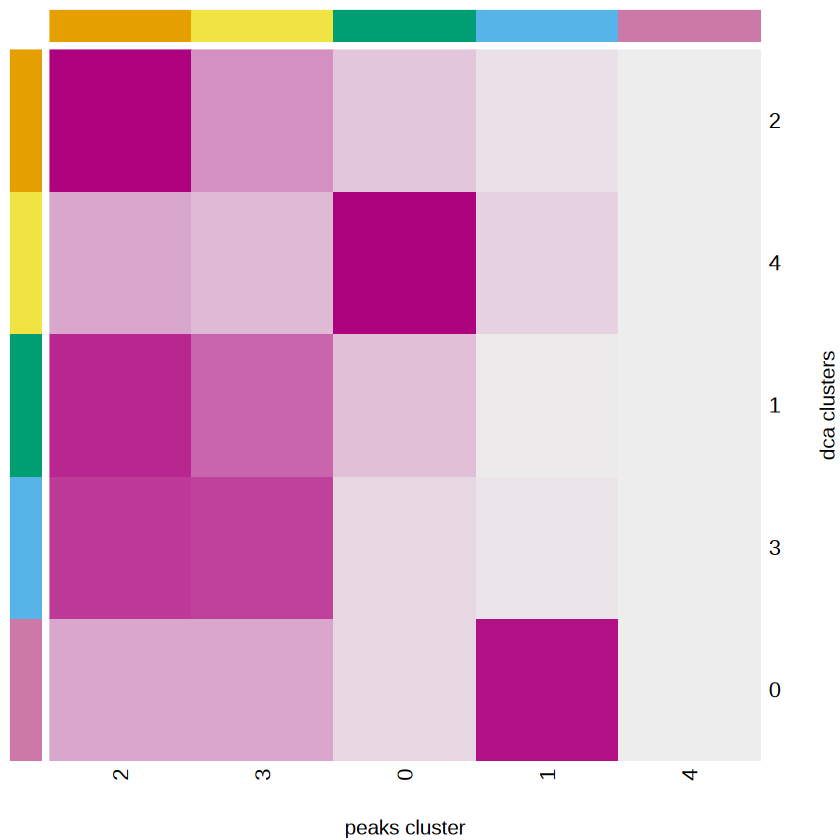

In [112]:
# Check the proportion of spots assigned to each cluster when using denoised vs original data
prop <- prop.table(table(signac_filtered$peaks_snn_res.0.5, signac_filtered$dca_snn_res.0.5), 1)*100
heatmap(prop[order(nrow(prop):1),], 
        Colv = NA, Rowv = NA, scale="none", 
        xlab="peaks cluster", ylab="dca clusters", 
        col = hm_colors, RowSideColors=rev(colors_okate), ColSideColors = colors_okate)

In [ ]:
saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "3_selected_", SELECTED_sATAC_SAMPLE,"_compared_brca_denoised_peaks.rds"))

---
# 5. - Gene activity

In [ ]:
# signac_filtered <- readRDS("output/sATAC_preprocessing/filtered_compared_brca_denoised_peaks.rds")

In [11]:
# calculate gene activity
DefaultAssay(signac_filtered) <- "peaks"
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- 'UCSC'
Annotation(signac_filtered) <- annotations
gene.activities <- GeneActivity(signac_filtered)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [13]:
# add the gene activity matrix to the Seurat object as a new assay and normalize it
#remove PCDH and UGT genes
gene.activities <- gene.activities[-grep("PCDH", rownames(gene.activities)),]
gene.activities <- gene.activities[-grep("UGT", rownames(gene.activities)),]
signac_filtered[['RNA']] <- CreateAssayObject(counts = gene.activities)

Warning message:
"Different cells and/or features from existing assay RNA"


ERROR: [1m[33mError[39m in `LayerData()`:[22m
[1m[22m[33m![39m `features` must be a character vector, not `NULL`.


In [ ]:
write.csv(signac_filtered@assays$RNA@counts, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca.csv"))

## 5.1 - DCA for gene activity
Run DCA on terminal
```sh
nohup dca output/sATAC_preprocessing/gene_activity_selected_<SAMPLE_NAME>_brca.csv output/sATAC_preprocessing/dca_gene_activity_selected_<SAMPLE_NAME>_brca --threads 6 --saveweights > nohup_for_<SAMPLE_NAME>_dca_gene_activity.out &
```

In [8]:
signac_filtered

An object of class Seurat 
447697 features across 3538 samples within 3 assays 
Active assay: peaks (215978 features, 215978 variable features)
 2 layers present: counts, data
 2 other assays present: dca, RNA
 2 dimensional reductions calculated: lsi, umap

In [ ]:
# gene activity
signac_filtered[["dca"]] <- NULL
mtx <- read.table(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "dca_gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca/mean.tsv"))
colnames(mtx) <- gsub("\\.", "-", colnames(mtx))
DefaultAssay(signac_filtered) <- "RNA"
signac_filtered <- subset(signac_filtered, cells = colnames(mtx))

# add denoised matrix to object
signac_filtered[["RNA_dca"]] <- CreateAssayObject(counts = as.matrix(mtx))
rm(mtx)

In [ ]:
saveRDS(signac_filtered, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "4_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA.rds"))